## Aim: Predict an IPL run chase

Data collected from an open Kaggle sources https://www.kaggle.com/datasets/chaitu20/ipl-dataset2008-2025

The premise of this exercise is to identify how accurately an IPL run chase can be predicted in this T20 format. How close, on simple hardware, can we model this seemingly volatile sport through utilising data engineering and machine learning techniques?

This model will be used throughout the 2026 IPL season. With this in mind, this model is evaluated using seasons 2019, 2022, 2023 and trained using data from seasons 2008 - 2025 (excluding test). This split tried to balance accessing key recent trends while being able to reliably evaluate performance.

A baseline of Linear Regression was used to gauge performance improvements in more costly and complex models. An untuned MAE = 21 was achieved. Here features were also reduced as performance was found to increase.

Ultimately of the Machine Learning methods tested all dramatically improved upon the LR baseline. XGBoost Regressor performed the best and was hyperparameter tuned to an MAE = 11.44. The results are evaluated in section 11 and stand up to the scrutiny of Residual analysis and a Q-Q plot analysis. To further emphasise validity, a heuristic trend of increased predictability as the match progresses was also shown by the model. This was found to be an increase in average absolute error of ∼ 1 run per 1 increase of balls left.

This workflow is split into 12 sections:

1. Data Load & inspection
2. Preliminary EDA
3. Preprocessing & Feature Engineering
4. Data Splitting
5. Numerical EDA
6. Categorical EDA
7. Pipeline Construction
8. Baseline Model
9. Advanced Modelling
10. Hyperparameter Tuning
11. Predictions & Evaluation
12. Save

### 1. Data Load & inspection

In [166]:
import pandas as pd

df = pd.read_csv('IPL_data.csv')
df

/tmp/ipykernel_1432/737826771.py:3: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL_data.csv')


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278200,277951,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,2,...,162,116,7,NaN,39,26,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278201,277952,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,3,...,168,117,7,NaN,45,27,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278202,277953,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,4,...,172,118,7,NaN,49,28,0,"('KA Jamieson', 'Shashank Singh')",NaN,False
278203,277954,1473511,2025-06-03,T20,Indian Premier League,2,Punjab Kings,Royal Challengers Bengaluru,19,5,...,178,119,7,NaN,55,29,0,"('KA Jamieson', 'Shashank Singh')",NaN,False


In [167]:
df.columns

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='object')

In [168]:
df = df.drop(columns=['Unnamed: 0'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 63 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           278205 non-null  int64  
 1   date               278205 non-null  object 
 2   match_type         278205 non-null  object 
 3   event_name         278205 non-null  object 
 4   innings            278205 non-null  int64  
 5   batting_team       278205 non-null  object 
 6   bowling_team       278205 non-null  object 
 7   over               278205 non-null  int64  
 8   ball               278205 non-null  int64  
 9   ball_no            278205 non-null  float64
 10  batter             278205 non-null  object 
 11  bat_pos            278205 non-null  int64  
 12  runs_batter        278205 non-null  int64  
 13  balls_faced        278205 non-null  int64  
 14  bowler             278205 non-null  object 
 15  valid_ball         278205 non-null  int64  
 16  ru

In [169]:
# How many matches have been recorded?

matches_no = df['match_id'].nunique()

print(f'There is {matches_no} matches of data collection.')

There is 1169 matches of data collection.


In [170]:
# How many possible features can we use?

print(f'Number of Attributes: {len(df.columns)}')
print(f'Features: {df.columns.tolist()}')

Number of Attributes: 63
Features: ['match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


### 2. Preliminary EDA

#### Distribution of Final Run Scores

In [171]:
# Calculate the total runs for each batting team in each innings, add as a feature to df
df['final_runs'] = df.groupby(['match_id', 'innings', 'batting_team'])['team_runs'].transform('max')

==== Statistical Summary ====
Total Innings:    2365
Mean Score:       158.25919661733616
Std dev:   (+/-)  37.517419036559474
Max Score:        287


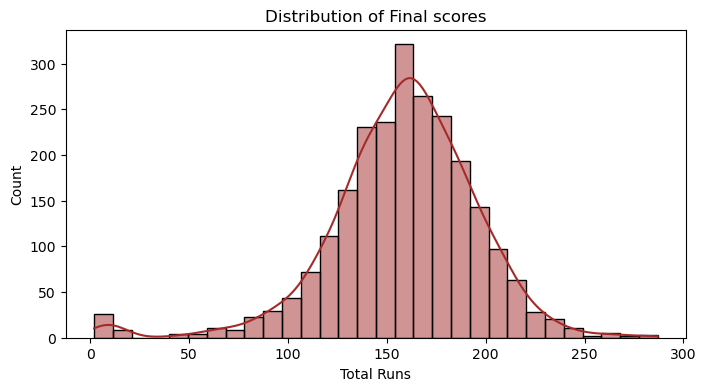

In [172]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the final runs for each innings/batting_team combination (not overcounting samples from the same match)
innings_data = df.groupby(['match_id', 'innings', 'batting_team'])['final_runs'].first().reset_index()

plt.figure(figsize=(8, 4))
sns.histplot(innings_data['final_runs'], bins=30, kde=True, color='brown')
plt.title('Distribution of Final scores')
plt.xlabel('Total Runs')
plt.ylabel('Count')

print("==== Statistical Summary ====")
print("Total Innings:   ", len(innings_data['final_runs']))
print("Mean Score:      ", innings_data['final_runs'].mean())
print("Std dev:   (+/-) ", innings_data['final_runs'].std())
print("Max Score:       ", innings_data['final_runs'].max())

#### Distribution of Bowlers' Economy

In [173]:
# Calculate
bowlers_runs = df.groupby(['bowler'])['runs_bowler'].sum()
bowlers_balls = df['bowler'].value_counts()

economy = (bowlers_runs / bowlers_balls) * 6

# Check
economy[0:10]

A Ashish Reddy     8.800000
A Badoni           8.400000
A Chandila         6.205128
A Choudhary        8.000000
A Dananjaya       11.280000
A Flintoff         9.545455
A Kamboj           8.666667
A Kumble           6.457782
A Mishra           7.221254
A Mithun           9.076923
dtype: float64

==== Economy Summary ===
No of Bowlers:    550
Mean :            8.913127692852283
Std  :            2.738164640832766
Max  :            36.0
Min  :            0.0


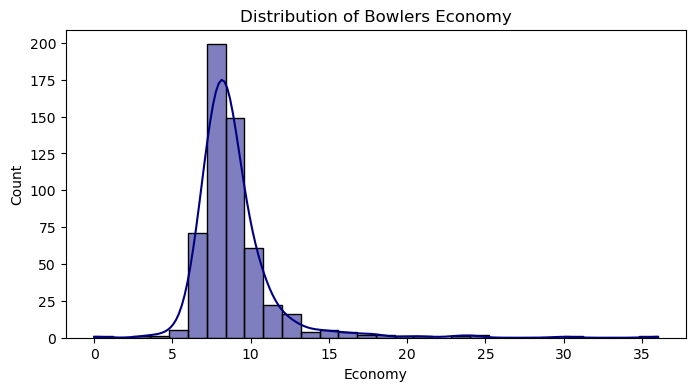

In [174]:
plt.figure(figsize=(8, 4))
sns.histplot(economy, bins=30, kde=True, color='navy')
plt.title('Distribution of Bowlers Economy')
plt.xlabel('Economy')
plt.ylabel('Count')

print('==== Economy Summary ===')
print('No of Bowlers:   ', len(economy))
print('Mean :           ', economy.mean())
print('Std  :           ', economy.std())
print('Max  :           ', economy.max())
print('Min  :           ', economy.min())

#### Distribution of Batters' Strike Rate

In [175]:
# Calculate
batters_runs = df.groupby(['batter'])['runs_batter'].sum()
batter_balls = df['batter'].value_counts()

strike_rate = (batters_runs / batter_balls) * 100
# Check
strike_rate[0:10]

A Ashish Reddy    142.857143
A Badoni          130.135135
A Chandila         57.142857
A Chopra           70.666667
A Choudhary       125.000000
A Dananjaya        80.000000
A Flintoff        108.771930
A Kamboj          106.666667
A Kumble           71.428571
A Manohar         120.164609
dtype: float64

==== SR Summary ===
No of Batters:    703
Mean :            103.32199724072716
Std  :            40.88295660466812
Max  :            300.0
Min  :            0.0


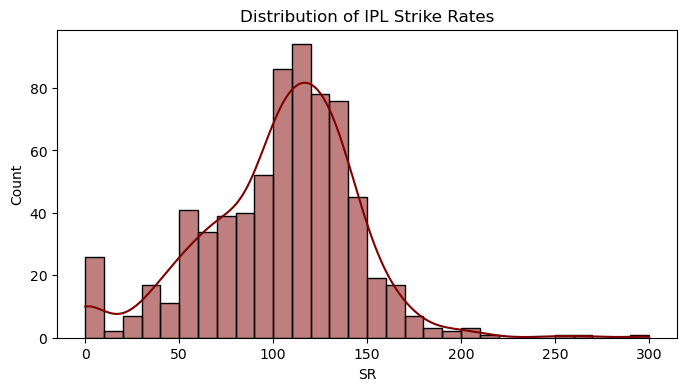

In [176]:
# Plot
plt.figure(figsize=(8, 4))
sns.histplot(strike_rate, bins=30, kde=True, color='maroon')
plt.title('Distribution of IPL Strike Rates')
plt.xlabel('SR')
plt.ylabel('Count')

print('==== SR Summary ===')
print('No of Batters:   ', len(strike_rate))
print('Mean :           ', strike_rate.mean())
print('Std  :           ', strike_rate.std())
print('Max  :           ', strike_rate.max())
print('Min  :           ', strike_rate.min())

#### Investigating Run Score & Wicket taking over time

- Look for trends to account for in later modelling

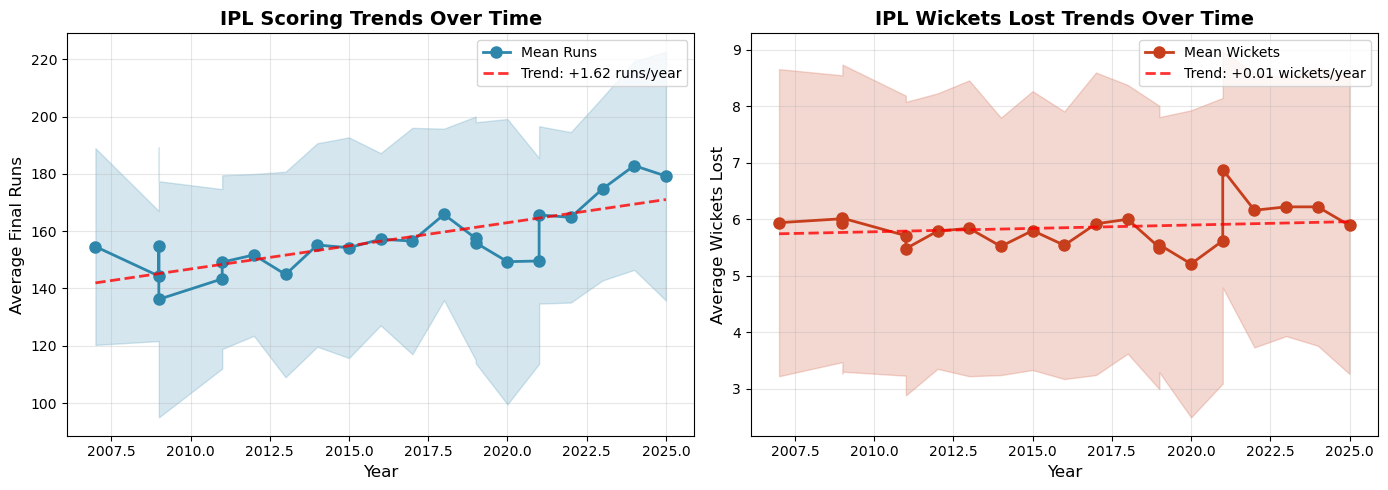


 SUMMARY:
   First season (2007): 154.6 runs avg
   Last season (2025): 179.2 runs avg


In [177]:
import numpy as np

# Get the final ball of each innings (to get final stats)
df_season = df.groupby(['match_id', 'innings', 'batting_team']).last().reset_index()

# Calculate season final runs & wickets lost each season mean, std
season_stats = df_season.groupby('season').agg({
    'final_runs': ['mean', 'std', 'count'],
    'team_wicket': ['mean', 'std']  # Final wickets lost
}).round(2)
season_stats.columns = ['_'.join(col).strip() for col in season_stats.columns]
season_stats = season_stats.reset_index()

# Extract year for plotting
def extract_year(season_str):
    if '/' in str(season_str):
        return int(str(season_str).split('/')[0])
    else:
        return int(season_str)

season_stats['year'] = season_stats['season'].apply(extract_year)
season_stats = season_stats.sort_values('year')  # Sort by year

# Create two simple plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Final Runs Trend
axes[0].plot(season_stats['year'], season_stats['final_runs_mean'], 
             marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Mean Runs')
axes[0].fill_between(season_stats['year'], 
                      season_stats['final_runs_mean'] - season_stats['final_runs_std'],
                      season_stats['final_runs_mean'] + season_stats['final_runs_std'],
                      alpha=0.2, color='#2E86AB')
# Add trendline
z = np.polyfit(season_stats['year'], season_stats['final_runs_mean'], 1)
p = np.poly1d(z)
axes[0].plot(season_stats['year'], p(season_stats['year']), 
             "r--", alpha=0.8, linewidth=2, label=f'Trend: {z[0]:+.2f} runs/year')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Average Final Runs', fontsize=12)
axes[0].set_title('IPL Scoring Trends Over Time', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Wickets Lost Trend
axes[1].plot(season_stats['year'], season_stats['team_wicket_mean'], 
             marker='o', linewidth=2, markersize=8, color='#C73E1D', label='Mean Wickets')
axes[1].fill_between(season_stats['year'], 
                      season_stats['team_wicket_mean'] - season_stats['team_wicket_std'],
                      season_stats['team_wicket_mean'] + season_stats['team_wicket_std'],
                      alpha=0.2, color='#C73E1D')
# Add trendline
z2 = np.polyfit(season_stats['year'], season_stats['team_wicket_mean'], 1)
p2 = np.poly1d(z2)
axes[1].plot(season_stats['year'], p2(season_stats['year']), 
             "r--", alpha=0.8, linewidth=2, label=f'Trend: {z2[0]:+.2f} wickets/year')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Average Wickets Lost', fontsize=12)
axes[1].set_title('IPL Wickets Lost Trends Over Time', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate overall trends
runs_trend = z[0]
wickets_trend = z2[0]


print(f"\n SUMMARY:")
print(f"   First season ({season_stats['year'].min()}): {season_stats.iloc[0]['final_runs_mean']:.1f} runs avg")
print(f"   Last season ({season_stats['year'].max()}): {season_stats.iloc[-1]['final_runs_mean']:.1f} runs avg")
print("="*60)

- Generally small season-by-season trends, though the difference becomes significant when considering the the first/last year of data
- Future modelling can assume seasonality independence - though consideration must be paid including enough recent seasons to train on, whilst ensuring recent seasons are saved to test the model on - to reliably evaluate its performance for 2026 season

### 3. Preprocessing & Feature Engineering

In [178]:
# Select Features

df_model = df[['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'batter', 'runs_target', 'bowler', 'final_runs']]

df_model.columns

Index(['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'batter',
       'runs_target', 'bowler', 'final_runs'],
      dtype='object')

In [179]:
# Build a function to convert Overs (decimal) to balls (int)

def over_to_balls(overs):
    over_no = np.floor(overs)
    intra_over_balls = (overs - over_no) * 10

    return (over_no * 6) + intra_over_balls

# Tests
over_to_balls(10.4), over_to_balls(0.1)

(64.0, 1.0)

In [180]:
df_model = df_model.copy()

In [181]:
# Want to view a feature with 'balls_left', 'current_score', 'wickets'

df_model['balls_left'] = 120 - over_to_balls(df['ball_no']).astype(int)
df_model['current_score'] = df['team_runs']
df_model['wickets'] = 10 - df['team_wicket']
balls_bowled = over_to_balls(df['ball_no']).astype(int)
df_model['current_rr'] = df['team_runs'] / (balls_bowled / 6).replace(0, np.nan)
df_model['required_rr'] = (df['runs_target'] - df['team_runs']) / (df_model['balls_left'] / 6).replace(0, np.nan)

# Mapping Strike rate and economy to specific batter and bowler respectively

df_model['strike_rate'] = df['batter'].map(strike_rate)
df_model['economy'] = df['bowler'].map(economy)


In [182]:
df_model.head()

,match_id,season,venue,batting_team,bowling_team,batter,runs_target,bowler,final_runs,balls_left,current_score,wickets,current_rr,required_rr,strike_rate,economy
0,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,NaN,P Kumar,222,119,1,10,6.0,NaN,101.734540,7.397042
1,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,NaN,P Kumar,222,118,1,10,3.0,NaN,126.848592,7.397042
2,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,NaN,P Kumar,222,117,2,10,4.0,NaN,126.848592,7.397042
3,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,NaN,P Kumar,222,117,2,10,4.0,NaN,126.848592,7.397042
4,335982,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,NaN,P Kumar,222,116,2,10,3.0,NaN,126.848592,7.397042


In [183]:
df_model = df_model.dropna(subset='runs_target')
df_model = df_model.dropna(subset=['required_rr']) # end of an innings (balls_left=0)

In [184]:
# Check for number of final samples

len(df_model)

133435

In [185]:
# Dropping as bowler and batter are represented by rr & sr

df_model = df_model.drop(columns=['batter', 'bowler', 'runs_target', 'current_score']) 

### 4. Data Splitting

In [186]:
df['season'].unique()

array(['2007/08', '2009', 2009, '2009/10', '2011', 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, '2019', '2020/21', '2021', 2021,
       2022, 2023, 2024, 2025], dtype=object)

In [187]:
# Split by season to avoid data leakage

# Get unique matches per season
match_seasons = df[['match_id', 'season']].drop_duplicates()

# Split by season
train_seasons = ['2007/08', '2009', 2009, '2009/10', '2011', 2011, 2012, 2014, 
                 2015, 2016, 2018, 2017, '2021', '2020/21', 2025, 2024]
test_seasons = ['2019', 2022, 2023, 2019]

# Create train/test based on match_id
train_matches = match_seasons[match_seasons['season'].isin(train_seasons)]['match_id']
test_matches = match_seasons[match_seasons['season'].isin(test_seasons)]['match_id']

# Split the data
df_train = df_model[df_model['match_id'].isin(train_matches)]
df_test = df_model[df_model['match_id'].isin(test_matches)]

X_train = df_train.drop(columns=['final_runs'])
y_train = df_train['final_runs']
X_test = df_test.drop(columns=['final_runs'])
y_test = df_test['final_runs']

In [188]:
train_pct = 100 * len(X_train) / (len(X_train) + len(X_test)) 
test_pct = 100 * len(X_test) / (len(X_train) + len(X_test))
print('Data Split Proportions...')
print(f'Train : {train_pct:.2f} %')
print(f'Test  : {test_pct:.2f} %\n')

(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Data Split Proportions...
Train : 79.72 %
Test  : 20.28 %



((95079, 11), (24194, 11), (95079,), (24194,))

In [189]:
# Dropping seasons to avoid unseen data in y, macth_id as its now no longer needed

X_test = X_test.drop(columns=['season', 'match_id'])
X_train = X_train.drop(columns=['season', 'match_id'])

In [190]:
X_train.head()

,venue,batting_team,bowling_team,balls_left,wickets,current_rr,required_rr,strike_rate,economy
124,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,119,10,6.0,11.193277,113.347237,7.827565
125,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,118,10,6.0,11.237288,100.775194,7.827565
126,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,118,10,6.0,11.237288,100.775194,7.827565
127,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,117,10,6.0,11.282051,100.775194,7.827565
128,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,116,10,6.0,11.327586,113.347237,7.827565


### 5. Numerical EDA

In [191]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include='object').columns.tolist()

X_train[num_cols].describe()

,balls_left,wickets,current_rr,required_rr,strike_rate,economy
count,95079.000000,95079.000000,95079.000000,95079.000000,95079.000000,95079.000000
mean,63.532757,7.548733,7.793761,10.605182,126.670137,7.875285
std,33.211601,2.131152,2.480310,12.227827,16.765707,0.877335
min,1.000000,0.000000,0.000000,-30.000000,0.000000,3.500000
25%,35.500000,6.000000,6.500000,7.221239,118.791064,7.296809
50%,65.000000,8.000000,7.725000,9.000000,128.571429,7.756098
75%,92.000000,9.000000,9.066667,11.195122,134.844785,8.324225
max,119.000000,10.000000,42.000000,588.000000,300.000000,30.000000


<Axes: >

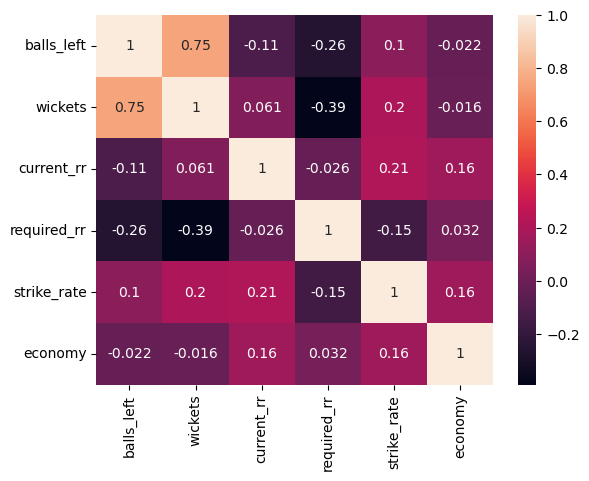

In [192]:
import seaborn as sns

sns.heatmap(X_train[num_cols].corr(), annot=True)

- Features are generally uncorrelated
- `wickets` & `balls_left` have a correlation of + 0.75
- This is can due to inherent patterns of T20, for instance wickets tend to be taken frquently at the end of matches where more risk is taken / bowlers are batting as well as the general trend of wickets increasing as the match progresses. Wickets taken is an indirect measure of the stage of a match. More investigation to ascertain whether to keep both features

array([[<Axes: title={'center': 'balls_left'}>,
        <Axes: title={'center': 'wickets'}>],
       [<Axes: title={'center': 'current_rr'}>,
        <Axes: title={'center': 'required_rr'}>],
       [<Axes: title={'center': 'strike_rate'}>,
        <Axes: title={'center': 'economy'}>]], dtype=object)

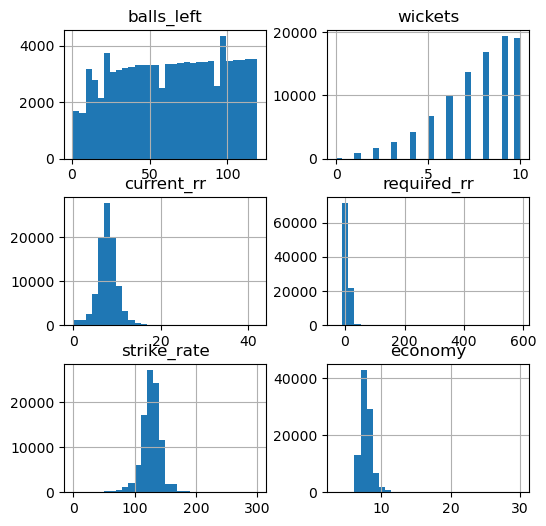

In [193]:
X_train[num_cols].hist(bins=30, figsize=(6, 6))

#### Feature Scaling

- `wickets`, `balls_left` MinMaxScaler()
- `current_rr` StandardScaler()
- `economy`, `strike_rate`, `required_rr` RobustScaler()

In [ ]:
# Sanity check
X_train[num_cols].isna().sum()

balls_left     0
wickets        0
current_rr     0
required_rr    0
strike_rate    0
economy        0
dtype: int64

### 6. Categorical EDA

/tmp/ipykernel_1432/226646684.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


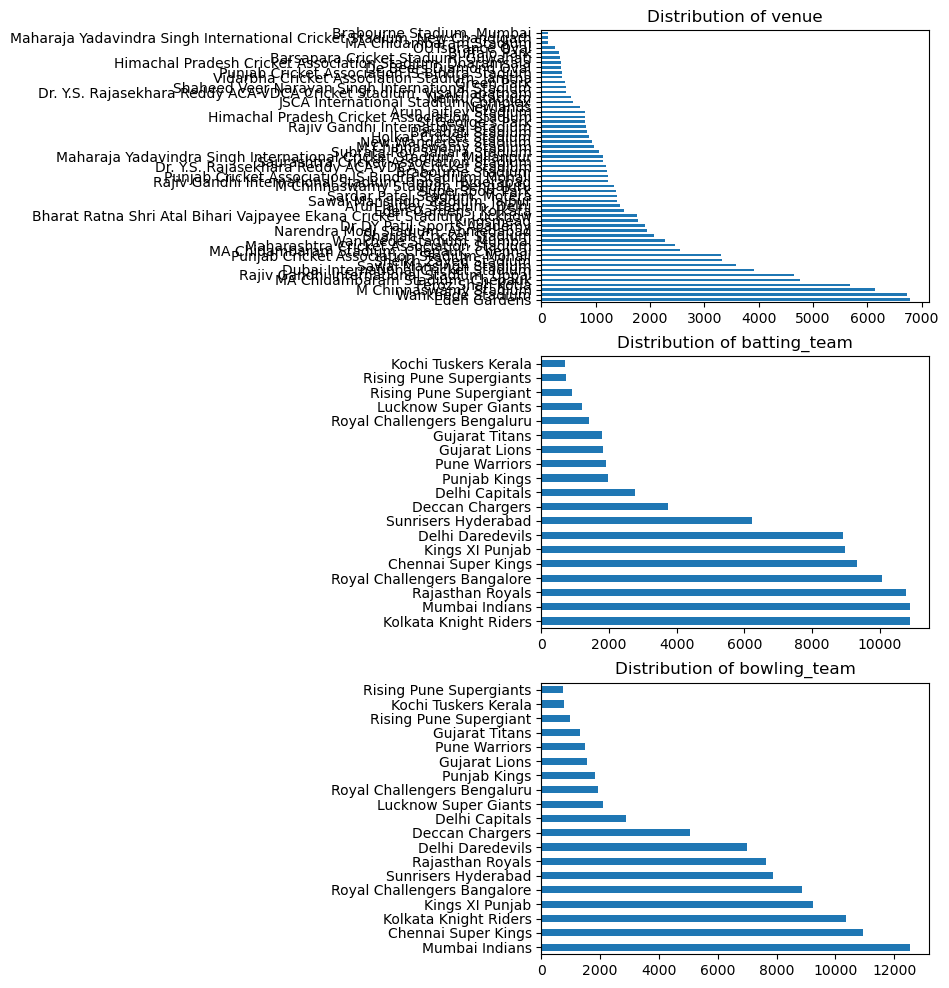

In [195]:
n_cols = len(cat_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(5, 4*n_cols))

if n_cols == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    X_train[col].value_counts().plot(kind='barh', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### 7. Pipeline Construction

In [196]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, MinMaxScaler, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder

# Define the log transform function
def log_transform(X):
    return np.log1p(X)


num_features = ['current_rr', 'strike_rate', 'economy', 'balls_left', 'wickets', 'required_rr']
cat_features = ['batting_team', 'bowling_team', 'venue']

# Create the full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        # Standard Scale current_rr
        ('standard_features', StandardScaler(), ['current_rr']),
        
        # RobustScale strike_rate, required_rr and economy
        ('robust_features', RobustScaler(), ['strike_rate', 'economy', 'required_rr']),
        
        # MinMaxScale balls_left
        ('minmax_features', MinMaxScaler(), ['balls_left', 'wickets']),
        
        
        # Target encode categorical features
        ('target_encode', TargetEncoder(cols=cat_features), cat_features),
        
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('standard_features', StandardScaler(),
                                 ['current_rr']),
                                ('robust_features', RobustScaler(),
                                 ['strike_rate', 'economy', 'required_rr']),
                                ('minmax_features', MinMaxScaler(),
                                 ['balls_left', 'wickets']),
                                ('target_encode',
                                 TargetEncoder(cols=['batting_team',
                                                     'bowling_team', 'venue']),
                                 ['batting_team', 'bowling_team', 'venue'])])

### 8. Baseline Model

In [197]:
# Prepare data
X_train_features = X_train[num_features + cat_features]
X_test_features = X_test[num_features + cat_features]

In [198]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

base = LinearRegression()

base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('base_model', base)
])


scores = cross_val_score(base_pipe, X_train_features, y_train, cv=5, scoring='neg_mean_absolute_error')

In [199]:
# Evaluate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

print('----Baseline Model Performance----\n(linear regression)\n')

print(f"MAE: {-scores.mean():.2f} (+/-) {scores.std():.2f}")

----Baseline Model Performance----
(linear regression)

MAE: 21.46 (+/-) 2.12



Feature Importance (Permutation):
current_rr          : 0.27225 (+/- 0.07803)
strike_rate         : -0.10622 (+/- 0.01566)
economy             : -0.09137 (+/- 0.00436)
balls_left          : 1.01730 (+/- 0.02606)
wickets             : 1.96657 (+/- 0.02718)
required_rr         : 1.55652 (+/- 0.03234)
batting_team        : 0.30379 (+/- 0.01545)
bowling_team        : 0.15077 (+/- 0.00697)
venue               : 0.05322 (+/- 0.00531)


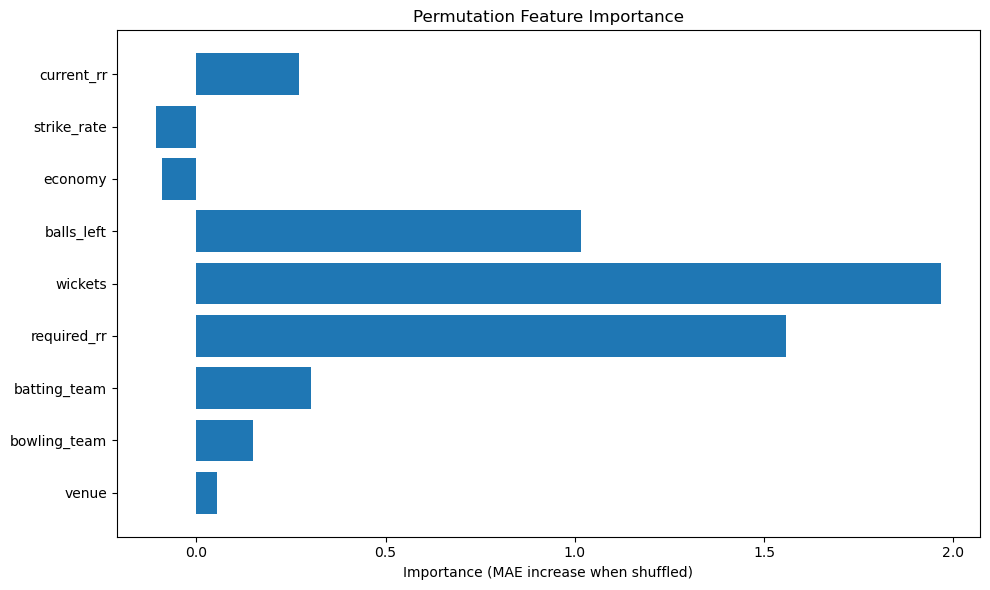

In [200]:
from sklearn.inspection import permutation_importance

base_pipe.fit(X_train_features, y_train)

# Perform permutation importance
results = permutation_importance(base_pipe, X_test, y_test, scoring='neg_mean_absolute_error')
# Get feature names
feature_names = X_test_features.columns.tolist()

# Print results
print("\nFeature Importance (Permutation):")
for i, (name, importance, std) in enumerate(zip(feature_names, 
                                                  results.importances_mean, 
                                                  results.importances_std)):
    print(f'{name:20s}: {importance:.5f} (+/- {std:.5f})')

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_names, results.importances_mean)
plt.xlabel('Importance (MAE increase when shuffled)')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()

In [205]:
important_features = ['balls_left', 'wickets', 'batting_team', 'current_rr', 'required_rr']

- These 5 features are identified as most important, with this in mind will the model perform better using these?

### 9. Advanced Modelling

In [206]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler, MinMaxScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder
import time

# Define both feature sets
num_features = ['current_rr', 'strike_rate', 'economy', 'balls_left', 'wickets', 'required_rr']
cat_features = ['batting_team', 'bowling_team', 'venue']
full_features = num_features + cat_features


# Test both feature sets
for feature_set_name, features in [('FULL FEATURES', full_features), 
                                     ('SIMPLIFIED FEATURES', important_features)]:
    
    print(f"\n{'='*60}")
    print(f"TESTING WITH: {feature_set_name}")
    print(f"Features: {features}")
    print(f"{'='*60}\n")
    
    # Create the appropriate preprocessor for this feature set
    if feature_set_name == 'FULL FEATURES':
        # Your original preprocessor
        preprocessor = ColumnTransformer(
            transformers=[
                # Standard Scale current_rr
                ('standard_features', StandardScaler(), ['current_rr']),
                # RobustScale strike_rate, required_rr and economy
                ('robust_features', RobustScaler(), ['strike_rate', 'economy', 'required_rr']),
                # MinMaxScale balls_left
                ('minmax_features', MinMaxScaler(), ['balls_left', 'wickets']),
                # Target encode categorical features
                ('target_encode', TargetEncoder(cols=cat_features), cat_features),

            ],
            remainder='drop'
        )
    else:
        # Simplified preprocessor for important_features : 'balls_left', 'wickets', 'batting_team', 'current_rr', 'required_rr'
        preprocessor = ColumnTransformer(
            transformers=[
                ('standard_features', StandardScaler(), ['current_rr']),
                ('robust_features', RobustScaler(), ['required_rr']),
                ('minmax_features', MinMaxScaler(), ['balls_left', 'wickets']),
                ('target_encode', TargetEncoder(cols=['batting_team']), ['batting_team'])
            ],
            remainder='drop'
        )
    
    # Get the appropriate data
    X_train_subset = X_train[features]
    
    model_dict = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'XGBoost': XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for model_name, model in model_dict.items():
        print(f"Training {model_name}...")
        
        # Create pipeline with this model
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        # Start timer
        start_time = time.time()
        
        cv_scores = cross_val_score(pipeline, X_train_subset, y_train, 
                                     cv=5, 
                                     scoring='neg_mean_absolute_error',
                                     n_jobs=-1)
        
        # End timer
        elapsed_time = time.time() - start_time
        
        mae_scores = -cv_scores
        results[model_name] = {
            'MAE_mean': mae_scores.mean(),
            'MAE_std': mae_scores.std(),
            'CV_scores': mae_scores,
            'time': elapsed_time
        }
        
        print(f"  MAE: {mae_scores.mean():.2f} (+/- {mae_scores.std():.2f})")
        print(f"  Time: {elapsed_time:.2f}s\n")
    
    print(f"\n{feature_set_name} - Best Model: {min(results.items(), key=lambda x: x[1]['MAE_mean'])[0]}")
    print(f"Best MAE: {min(results.values(), key=lambda x: x['MAE_mean'])['MAE_mean']:.2f}\n")



TESTING WITH: FULL FEATURES
Features: ['current_rr', 'strike_rate', 'economy', 'balls_left', 'wickets', 'required_rr', 'batting_team', 'bowling_team', 'venue']

Training Linear Regression...
  MAE: 21.46 (+/- 2.12)
  Time: 0.55s

Training Decision Tree...
  MAE: 16.62 (+/- 0.84)
  Time: 1.74s

Training KNN...
  MAE: 26.79 (+/- 1.80)
  Time: 2.74s

Training XGBoost...
  MAE: 13.17 (+/- 1.78)
  Time: 1.94s


FULL FEATURES - Best Model: XGBoost
Best MAE: 13.17


TESTING WITH: SIMPLIFIED FEATURES
Features: ['balls_left', 'wickets', 'batting_team', 'current_rr', 'required_rr']

Training Linear Regression...
  MAE: 21.91 (+/- 2.53)
  Time: 0.55s

Training Decision Tree...
  MAE: 14.71 (+/- 0.59)
  Time: 1.00s

Training KNN...
  MAE: 15.08 (+/- 0.95)
  Time: 0.92s

Training XGBoost...
  MAE: 11.89 (+/- 1.47)
  Time: 0.96s


SIMPLIFIED FEATURES - Best Model: XGBoost
Best MAE: 11.89



- All models perform better than the Linear Regression baseline
- Models that can capture non-linearity have lower MAE
- Dimensionality reduction is favoured generally
- Lifetime Strike Rate & Economy stats for bowlers and batter shows little significance in one-off match predictions
- XGBoost performs the best, will be further tuned
- Simplifying the features dramatically increases performance at cheaper computational cost
- This also decreasing complexity which should help generalisation for future unseen data

### 10. Hyperparameter Tuning

In [233]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

preprocessor_final = ColumnTransformer(
            transformers=[
                ('standard_features', StandardScaler(), ['current_rr']),
                ('robust_features', RobustScaler(), ['required_rr']),
                ('minmax_features', MinMaxScaler(), ['balls_left', 'wickets']),
                ('target_encode', TargetEncoder(cols=['batting_team']), ['batting_team'])
            ],
            remainder='drop'
)

xgb_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7, 10],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.3],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

xgb_pipeline = Pipeline([
    ('preprocessor_final', preprocessor_final),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

xgb_grid = RandomizedSearchCV(
    xgb_pipeline, 
    xgb_params,
    cv=5,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1)

xgb_grid.fit(X_train_features[important_features], y_train)
print(f"Best XGBoost MAE: {-xgb_grid.best_score_:.2f}")
print(f"Best params: {xgb_grid.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost MAE: 10.92
Best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


In [213]:
xgb_grid.best_estimator_

Pipeline(steps=[('preprocessor_final',
                 ColumnTransformer(transformers=[('standard_features',
                                                  StandardScaler(),
                                                  ['current_rr']),
                                                 ('robust_features',
                                                  RobustScaler(),
                                                  ['required_rr']),
                                                 ('minmax_features',
                                                  MinMaxScaler(),
                                                  ['balls_left', 'wickets']),
                                                 ('target_encode',
                                                  TargetEncoder(cols=['batting_team']),
                                                  ['batting_team'])])),
                ('model',
                 XGBRegressor(base_score=None, bo...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None, min_child_weight=5,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=200,
                              n_jobs=None, num_parallel_tree=None,
                              random_state=42, ...))])

### 11. Predictions & Evaluation

In [234]:
y_pred_final = xgb_grid.best_estimator_.predict(X_test[important_features])

print('---- Final Model Performance ----\n(Hyperparameter Tuned XGBoost Regressor)\n')

print(f"     MAE:   {mean_absolute_error(y_test, y_pred_final):.2f}")
print(f"    MAPE:   {mean_absolute_percentage_error(y_test, y_pred_final)*100:.2f}%")
print(f"R2 Score:   {r2_score(y_test, y_pred_final):.4f}")
print(f"    RMSE:   {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}")

---- Final Model Performance ----
(Hyperparameter Tuned XGBoost Regressor)

     MAE:   11.35
    MAPE:   7.77%
R2 Score:   0.6454
    RMSE:   17.32


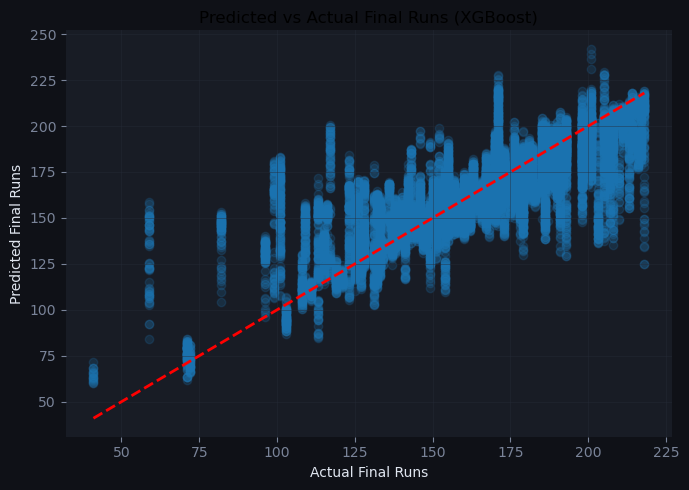

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_final, alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Final Runs')
plt.ylabel('Predicted Final Runs')
plt.title('Predicted vs Actual Final Runs (XGBoost)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

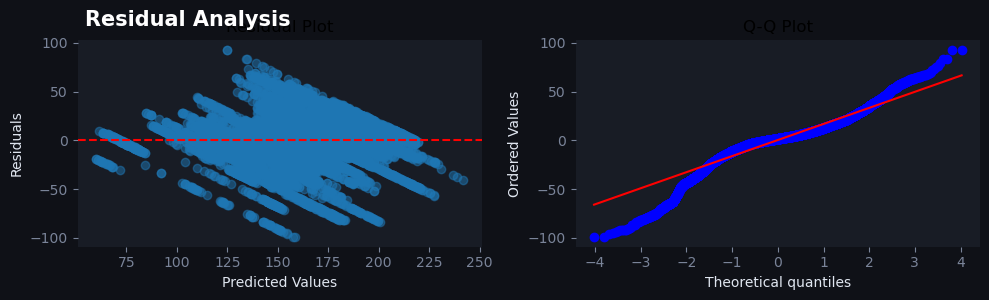


 RESIDUAL STATISTICS:
Mean Residual: 0.32
Std Residual: 17.32
Min Residual: -99.50
Max Residual: 92.93
Max Absolute Error: 99.50


In [241]:
# Calculate residuals
residuals = y_test - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# 1. Residual plot
axes[0].scatter(y_pred_final, residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

# 2. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

fig.text(0.09, 0.93, "Residual Analysis",
         fontsize=15, fontweight="bold", color='white', ha="left")
plt.tight_layout()
plt.show()

print("\n RESIDUAL STATISTICS:")
print(f"Mean Residual: {residuals.mean():.2f}")
print(f"Std Residual: {residuals.std():.2f}")
print(f"Min Residual: {residuals.min():.2f}")
print(f"Max Residual: {residuals.max():.2f}")
print(f"Max Absolute Error: {np.abs(residuals).max():.2f}")

Residual Plot (left)

- The mean residual of 0.39 is essentially zero — the model has no meaningful systematic bias, it's not consistently over or under-predicting
- The funnel shape (wide spread at low predicted values, narrowing slightly toward higher ones) suggests heteroscedasticity — the model is less certain when predicting lower scores, likely because early-chase scenarios have more volatile outcomes
- The vertical "striping" patterns visible around 125–175 are concerning — these suggest the model is snapping predictions to a narrow set of values rather than producing a smooth continuous output, which is a classic XGBoost discretisation artefact when max_depth is low
- There are clear outliers beyond ±75 runs which will be inflating RMSE disproportionately relative to MAE

Q-Q Plot (right)

- The middle section (roughly -2 to +2 theoretical quantiles) tracks the red line well — residuals are approximately normal for the bulk of predictions
- Both tails deviate significantly, particularly the lower tail, meaning the model produces more extreme underpredictions than a normal distribution would suggest — these correspond to matches where a team collapsed unexpectedly
- The asymmetry (lower tail worse than upper) makes cricket sense: a team can collapse far below expectation more dramatically than they can overperform, since wickets create hard floors on scoring

Overall
The model is well-calibrated on average but struggles with edge cases — late-order collapses and explosive chases. These are inherently the hardest scenarios to predict and likely represent the bulk of max absolute error of 98.66 runs.

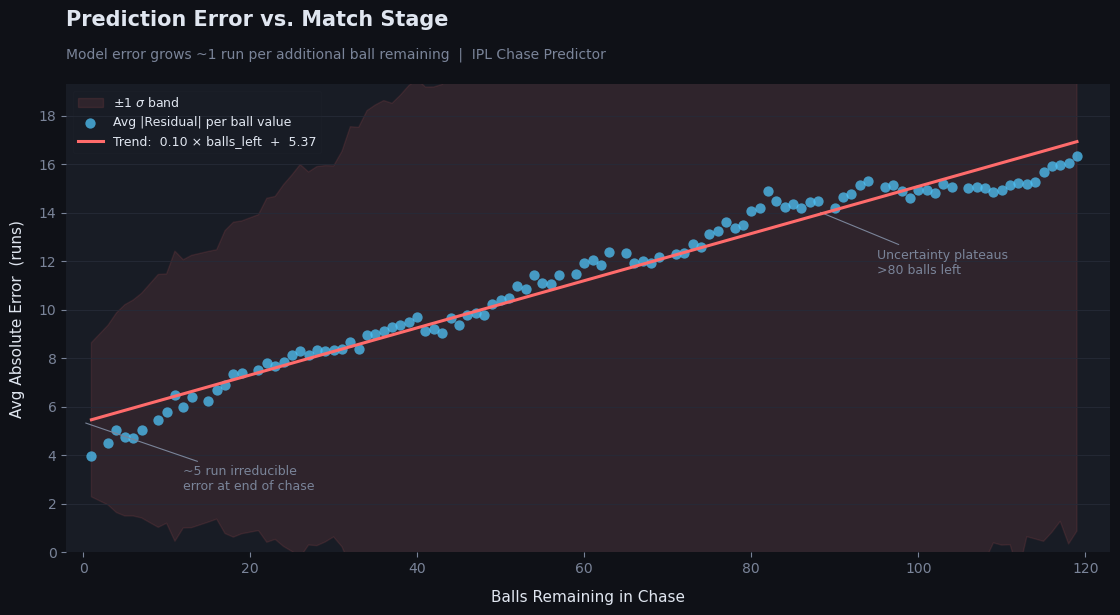

In [230]:
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from scipy.stats import linregress

# ── Assumes these exist in your namespace ──────────────────────────────────────
# residuals      : np.array of raw residuals (predicted - actual)
# X_test         : DataFrame with a 'balls_left' column
# ──────────────────────────────────────────────────────────────────────────────

balls_left_test = X_test['balls_left'].values
unique_balls    = np.unique(balls_left_test)
avg_abs_res     = np.array([np.mean(np.abs(residuals[balls_left_test == b])) for b in unique_balls])

slope, intercept, r, *_ = linregress(unique_balls, avg_abs_res)
trendline = slope * unique_balls + intercept

# ── Style ──────────────────────────────────────────────────────────────────────
BG       = "#0F1117"
PANEL    = "#181C25"
ACCENT   = "#4FC3F7"   # ice blue scatter
TREND    = "#FF6B6B"   # coral trendline
GRID     = "#262B38"
TEXT     = "#E0E6F0"
SUBTEXT  = "#7A8499"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.spines.left":  False,
    "axes.spines.bottom":False,
    "xtick.color":       SUBTEXT,
    "ytick.color":       SUBTEXT,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
})

fig = plt.figure(figsize=(12, 6.5), facecolor=BG)
gs  = GridSpec(1, 1, figure=fig, left=0.09, right=0.96, top=0.84, bottom=0.12)
ax  = fig.add_subplot(gs[0])

# Confidence band ±1 std of residuals per bucket
std_res = np.array([np.std(np.abs(residuals[balls_left_test == b])) for b in unique_balls])
ax.fill_between(unique_balls, trendline - std_res, trendline + std_res,
                color=TREND, alpha=0.10, zorder=1, label=r"±1 $\sigma$ band")

# Scatter
sc = ax.scatter(unique_balls, avg_abs_res,
                s=55, color=ACCENT, alpha=0.75, linewidths=0,
                zorder=3, label="Avg |Residual| per ball value")

# Trendline
ax.plot(unique_balls, trendline, color=TREND, linewidth=2.2, zorder=4,
        label=f"Trend:  {slope:.2f} × balls_left  +  {intercept:.2f}")

# Annotation — intercept meaning
ax.annotate("~{:.0f} run irreducible\nerror at end of chase".format(intercept),
            xy=(0, intercept), xytext=(12, intercept - 2.8),
            fontsize=9, color=SUBTEXT,
            arrowprops=dict(arrowstyle="-", color=SUBTEXT, lw=0.8))

# Annotation — plateau region
ax.annotate("Uncertainty plateaus\n>80 balls left",
            xy=(88, avg_abs_res[unique_balls >= 80][0]),
            xytext=(95, 11.5),
            fontsize=9, color=SUBTEXT,
            arrowprops=dict(arrowstyle="-", color=SUBTEXT, lw=0.8))

# Grid & axes
ax.yaxis.grid(True, zorder=0)
ax.set_xlim(-2, 123)
ax.set_ylim(0, avg_abs_res.max() * 1.18)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

ax.set_xlabel("Balls Remaining in Chase", labelpad=10, fontsize=11, color=TEXT)
ax.set_ylabel("Avg Absolute Error  (runs)", labelpad=10, fontsize=11, color=TEXT)

# Title block
fig.text(0.09, 0.93, "Prediction Error vs. Match Stage",
         fontsize=15, fontweight="bold", color=TEXT, ha="left")
fig.text(0.09, 0.88, "Model error grows ~1 run per additional ball remaining  |  IPL Chase Predictor",
         fontsize=10, color=SUBTEXT, ha="left")

# Legend
leg = ax.legend(frameon=True, framealpha=0.15, edgecolor=GRID,
                labelcolor=TEXT, fontsize=9, loc="upper left")

#plt.savefig("residual_plot.png", dpi=180, bbox_inches="tight", facecolor=BG)
plt.show()

- The ~ 0.98 slope means roughly 1 extra run of error per additional ball left
- The $\sigma$ band is still extremely large showing this error trend is very flattly distributed, therefore this trend should be taken with a grain of salt

### 12. Save

In [231]:
import joblib

# Save the full pipeline (preprocessor + model)
joblib.dump(xgb_grid.best_estimator_, 'cricket_model_xgb.pkl')

print(" Model saved successfully!")
print("Files created:")
print("  - cricket_model_xgb.pkl")


 Model saved successfully!
Files created:
  - cricket_model_xgb.pkl
